<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [137]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df = pd.read_csv('drive/MyDrive/ML for people/marketing_campaign.csv', sep='\t', engine='python')

In [47]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [49]:
num_col = df.select_dtypes(include='number').columns

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [50]:
df['Income'].median()

51381.5

In [51]:
df.groupby(['Education', 'Marital_Status'])['Income'].median()

Education   Marital_Status
2n Cycle    Divorced          49118.0
            Married           46462.5
            Single            48668.5
            Together          45774.0
            Widow             47682.0
Basic       Divorced           9548.0
            Married           22352.0
            Single            16383.0
            Together          23179.0
            Widow             22123.0
Graduation  Absurd            79244.0
            Alone             34176.0
            Divorced          55635.0
            Married           50737.0
            Single            49973.5
            Together          53977.0
            Widow             58275.0
Master      Absurd            65487.0
            Alone             61331.0
            Divorced          49476.0
            Married           53088.5
            Single            49494.0
            Together          49736.0
            Widow             51529.0
PhD         Alone             35860.0
            Divorced          50613.5
            Married           57081.5
            Single            50198.0
            Together          56756.0
            Widow             57032.0
            YOLO              48432.0
Name: Income, dtype: float64

In [52]:
##Задам медіанне значення Income по групам за освітою і сімейним станом, вважаю що це фічі які можуть найбільше впливати на дохід
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.median()))

In [53]:
df['Income'].isna().value_counts()

,count
Income,
False,2240


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

####Колонка дати

In [54]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [55]:
last_date = df['Dt_Customer'].max()

In [56]:
df['Dt_Customer'].max()

Timestamp('2014-06-29 00:00:00')

In [57]:
#Обчислимо як давно клієнт з нами, його "новизну" та використаєм як новий параметр для моделі
df['Recency'] = (last_date - df['Dt_Customer']).dt.days

#### Колонка Education

In [58]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [59]:
#Застосуємо OrdinalEncoder
edu_order = [['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
df['Education_order'] = oe.fit_transform(df[['Education']])

####Колонка Marital_status

In [60]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [61]:
#Перевіряємо наскільки багато значень з 'Absurd' i 'Yolo' так як медіанне значення доходу у кожної категорії досить високе
df[df['Marital_Status'].isin(['Absurd', 'YOLO'])]['Marital_Status'].value_counts()

,count
Marital_Status,
Absurd,2
YOLO,2


In [62]:
df[df['Marital_Status'] == 'Widow']['Year_Birth'].mean()

np.float64(1958.5584415584415)

In [63]:
#Створимо новий параметр який розділятиме сімейний стан на 3 категорії (Клод порадив виділити вдов окремо)

mapping = {
    'Married': 'Partner',
    'Together': 'Partner',
    'Single': 'Single',
    'Divorced': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Widow': 'Widow',
    'Alone': 'Single'
}
df['Marital_Group'] = df['Marital_Status'].map(mapping)

#### Колонка Year_Birth
трансформую цю колонку у вік. Максимальний рік в колонці Dt_Customer 2014, його і викорстаю як поточний

In [64]:
current_year = df['Dt_Customer'].max().year
df['Age'] = current_year - df['Year_Birth']

Застосую OHE і стандартизацію

In [65]:
num_col = df.select_dtypes(include='number').columns[2:].delete(-2)

In [66]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(df[['Marital_Group']])

transformed = ohe.transform(df[['Marital_Group']])
new_cols = ohe.get_feature_names_out(['Marital_Group'])
df[new_cols] = pd.DataFrame(transformed, columns=new_cols, index=df.index)

In [67]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Education_order,Marital_Group,Age,Marital_Group_Partner,Marital_Group_Single,Marital_Group_Widow
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,663,635,...,0,3,11,1,2.0,Single,57,0.0,1.0,0.0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,113,11,...,0,3,11,0,2.0,Single,60,0.0,1.0,0.0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,312,426,...,0,3,11,0,2.0,Partner,49,1.0,0.0,0.0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,139,11,...,0,3,11,0,2.0,Partner,30,1.0,0.0,0.0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,161,173,...,0,3,11,0,4.0,Partner,33,1.0,0.0,0.0


In [68]:
df.columns[4:].to_list().remove('Dt_Customer')

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [177]:
X = df[df.columns[4:]].copy().drop(columns=['Dt_Customer', 'Marital_Group'])
X.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_order,Age,Marital_Group_Partner,Marital_Group_Single,Marital_Group_Widow
0,58138.0,0,0,663,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,2.0,57,0.0,1.0,0.0
1,46344.0,1,1,113,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,2.0,60,0.0,1.0,0.0
2,71613.0,0,0,312,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,2.0,49,1.0,0.0,0.0
3,26646.0,1,0,139,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,2.0,30,1.0,0.0,0.0
4,58293.0,1,0,161,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4.0,33,1.0,0.0,0.0


In [178]:
X_nScl = X.copy()

In [70]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
s = metrics.silhouette_score(X, labels, metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


In [71]:
df_original = pd.read_csv('drive/MyDrive/ML for people/marketing_campaign.csv', sep='\t', engine='python')

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [72]:
fig = px.scatter_3d(
    df_original,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=labels.astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(legend_title_text='Cluster')
fig.show()

Виглядає так що кластери перекривають один одного, немає розмежування між ними, хоча коефіцієнт силуету досить високий - 0.60

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [240]:
scaler = StandardScaler()
X[num_col] = scaler.fit_transform(X[num_col])

In [94]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
s = metrics.silhouette_score(X, labels, metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.17


In [95]:
fig = px.scatter_3d(
    X,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=labels.astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(legend_title_text='Cluster')
fig.show()

Візуально не можу сказати що стало краще, все ще скупчені кластери, можливо зелений кластер краще відділений від решти, коефіцієнт Силуету дуже низький - 0.17

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [118]:
X_wo_outlrs = X.copy()

X_wo_outlrs = X_wo_outlrs[X_wo_outlrs['Income']< 2.4]
X_wo_outlrs = X_wo_outlrs[X_wo_outlrs['NumWebVisitsMonth']<=3]

In [119]:
kmeans_wo_outlrs = KMeans(n_clusters=3, n_init='auto')
kmeans_wo_outlrs.fit(X_wo_outlrs)

labels_wo_outlrs = kmeans_wo_outlrs.predict(X_wo_outlrs)
s = metrics.silhouette_score(X_wo_outlrs, labels_wo_outlrs, metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.22


In [120]:

fig_wo_outlrs = px.scatter_3d(
    X_wo_outlrs,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=labels_wo_outlrs.astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig_wo_outlrs.update_traces(marker=dict(size=4))
fig_wo_outlrs.update_layout(legend_title_text='Cluster')
fig_wo_outlrs.show()

Результат все ще слабкий, кластери накладаються один на оден.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

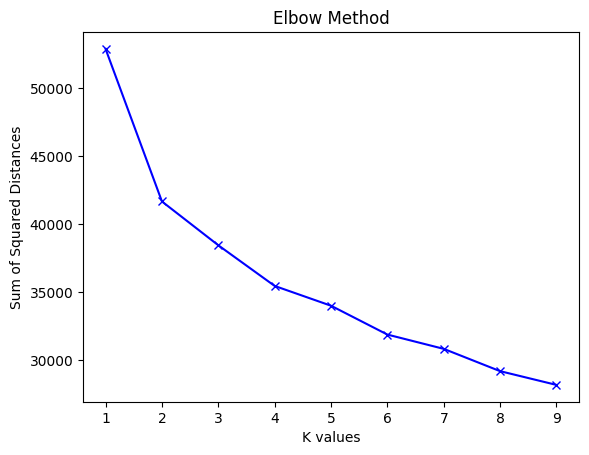

In [121]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_wo_outlrs)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [123]:
kmeans_4 = KMeans(n_clusters=4, n_init='auto')
kmeans_4.fit(X_wo_outlrs)

labels_4 = kmeans_4.predict(X_wo_outlrs)
s = metrics.silhouette_score(X_wo_outlrs, labels_4, metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.18


In [124]:
fig_4 = px.scatter_3d(
    X_wo_outlrs,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=labels_4.astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig_4.update_traces(marker=dict(size=4))
fig_4.update_layout(legend_title_text='Cluster')
fig_4.show()

Виглядає так, що основний акцент робиться на Income, тому що кластери міняють колір саме по вісі Income. 4ий кластер якось взагалі не додав інформативності - жовті точки (чи оранжеві, не розумію) якось хаотично розкидані по всьому простору

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [229]:
df_ = X_nScl[(df_original['Income'] < 140000) & (df_original['NumWebVisitsMonth'] <= 13)\
                  & (df_original['NumWebPurchases'] <= 10) & (df_original['NumCatalogPurchases'] <= 15)]
df_.shape

(2152, 29)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_order,Age,Marital_Group_Partner,Marital_Group_Single,Marital_Group_Widow
0,0.235922,-0.825218,-0.929894,1.531185,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,2.388846,2.0,0.985345,0.0,1.0,0.0
1,-0.235192,1.032559,0.906934,-1.190545,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,2.0,1.235733,0.0,1.0,0.0
2,0.774184,-0.825218,-0.929894,-0.205773,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,2.0,0.317643,1.0,0.0,0.0
3,-1.022033,1.032559,-0.929894,-1.061881,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,2.0,-1.268149,1.0,0.0,0.0
4,0.242114,1.032559,-0.929894,-0.953012,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,4.0,-1.017761,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.359153,-0.825218,0.906934,0.135680,1.203678,0.419916,0.066692,0.081926,2.203398,3.891766,-0.168236,1.769263,0.115638,-0.550785,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,2.0,0.150717,1.0,0.0,0.0
2236,0.470640,2.890335,0.906934,-1.655713,0.303291,-0.661449,-0.606873,-0.687068,-0.655733,-0.690659,2.420015,1.409304,-0.226541,-0.243114,0.693904,-0.28014,-0.283830,-0.28014,3.815174,-0.11651,-0.097282,0.0,0.0,-0.418612,4.0,1.903435,1.0,0.0,0.0
2237,0.189705,-0.825218,-0.929894,-0.982703,1.795020,0.545656,0.221789,-0.101168,-0.364974,-0.383886,-0.685887,-0.750450,0.115638,2.218248,0.281720,-0.28014,3.523233,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,2.0,-1.017761,0.0,1.0,0.0
2238,0.679594,-0.825218,0.906934,-0.977755,0.368666,0.092992,0.208495,0.777683,0.071165,0.325527,-0.168236,0.689386,0.799996,1.295237,-0.954831,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,3.0,1.068807,1.0,0.0,0.0


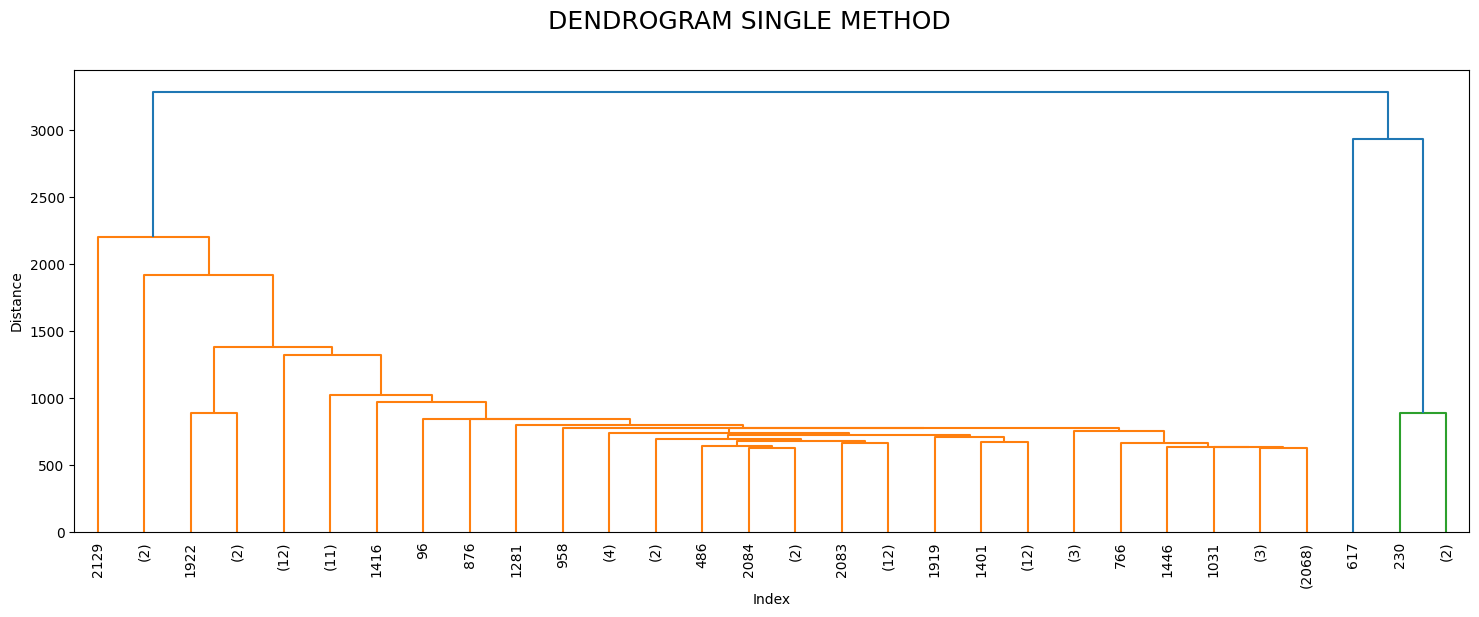

In [230]:
dist_sin = linkage(df_, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90,truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [231]:
from scipy.cluster.hierarchy import fcluster

# Призначаємо мітки кластерів при зрізі, наприклад на дистанції 3000
labels = fcluster(dist_sin, t=3000, criterion='distance')

# Дивимось який кластер маленький (outliers)
import pandas as pd
label_counts = pd.Series(labels).value_counts()
print(label_counts)

1    2148
2       4
Name: count, dtype: int64


In [232]:
# Знаходимо індекси рядків датафрейму що належать до малого кластера
outlier_label = label_counts.index[-1]  # найменший кластер
outlier_indices = df_.index[labels == outlier_label]
print(outlier_indices)

# Дивимось на них
df.loc[outlier_indices]

Index([124, 203, 252, 646], dtype='int64')


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_order,Marital_Group,Age,Marital_Group_Partner,Marital_Group_Single,Marital_Group_Widow
124,7215,1983,Graduation,Single,101970.0,0,0,2013-03-12,474,722,27,102,44,72,168,0,6,8,13,2,0,1,1,1,0,0,3,11,1,2.0,Single,31,0.0,1.0,0.0
203,2798,1977,PhD,Together,102160.0,0,0,2012-11-02,604,763,29,138,76,176,58,0,7,9,10,4,0,1,1,1,0,0,3,11,1,4.0,Partner,37,1.0,0.0,0.0
252,10089,1974,Graduation,Divorced,102692.0,0,0,2013-04-05,450,168,148,444,32,172,148,1,6,9,13,2,0,1,1,1,1,0,3,11,1,2.0,Single,40,0.0,1.0,0.0
646,4611,1970,Graduation,Together,105471.0,0,0,2013-01-21,524,1009,181,104,202,21,207,0,9,8,13,3,0,0,1,1,0,0,3,11,1,2.0,Partner,44,1.0,0.0,0.0


Вище, це клод мені намагався допомогти зрозуміти чому 4 значення так вибиваються і формують окремий кластер. Наче тому що це преміум сегмент - високий дохід і відзиваються на більшість кампаній. Але це погано для формування кластерів для решти типових клієнтів. трясця

<Axes: ylabel='Recency'>

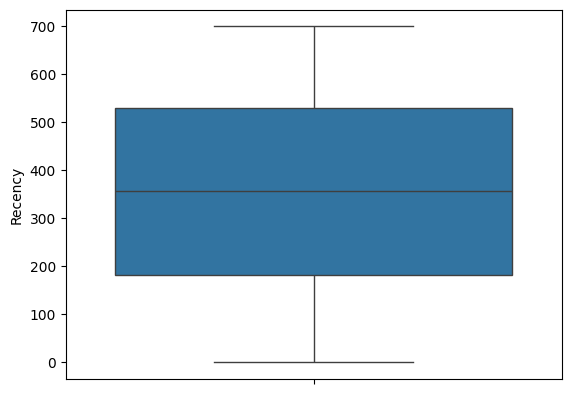

In [233]:
sns.boxplot(y = 'Recency', data = df)

In [234]:
df_['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
df_['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

/tmp/ipykernel_1779/4211123622.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1779/4211123622.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [235]:
s_2 = metrics.silhouette_score(df_, df_['2_clust'], metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s_2:.2f}')

s_3 = metrics.silhouette_score(df_, df_['3_clust'], metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s_3:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.45
Silhouette Coefficient for the data Dataset Clusters: 0.44


In [236]:
fig_fcl_2= px.scatter_3d(
    df_,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=df_['2_clust'].astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig_fcl_2.update_traces(marker=dict(size=4))
fig_fcl_2.update_layout(legend_title_text='Cluster')
fig_fcl_2.show()

In [237]:
fig_fcl_3= px.scatter_3d(
    df_,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=df_['3_clust'].astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig_fcl_3.update_traces(marker=dict(size=4))
fig_fcl_3.update_layout(legend_title_text='Cluster')
fig_fcl_3.show()

Виглядає що більшість даних просто скинуло в один кластер, на дендрограмі це теж було видно (через 4 нетипових клієнтів)

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [242]:
X_ = X[(df_original['Income'] < 140000) & (df_original['NumWebVisitsMonth'] <= 13)\
                  & (df_original['NumWebPurchases'] <= 10) & (df_original['NumCatalogPurchases'] <= 15)]

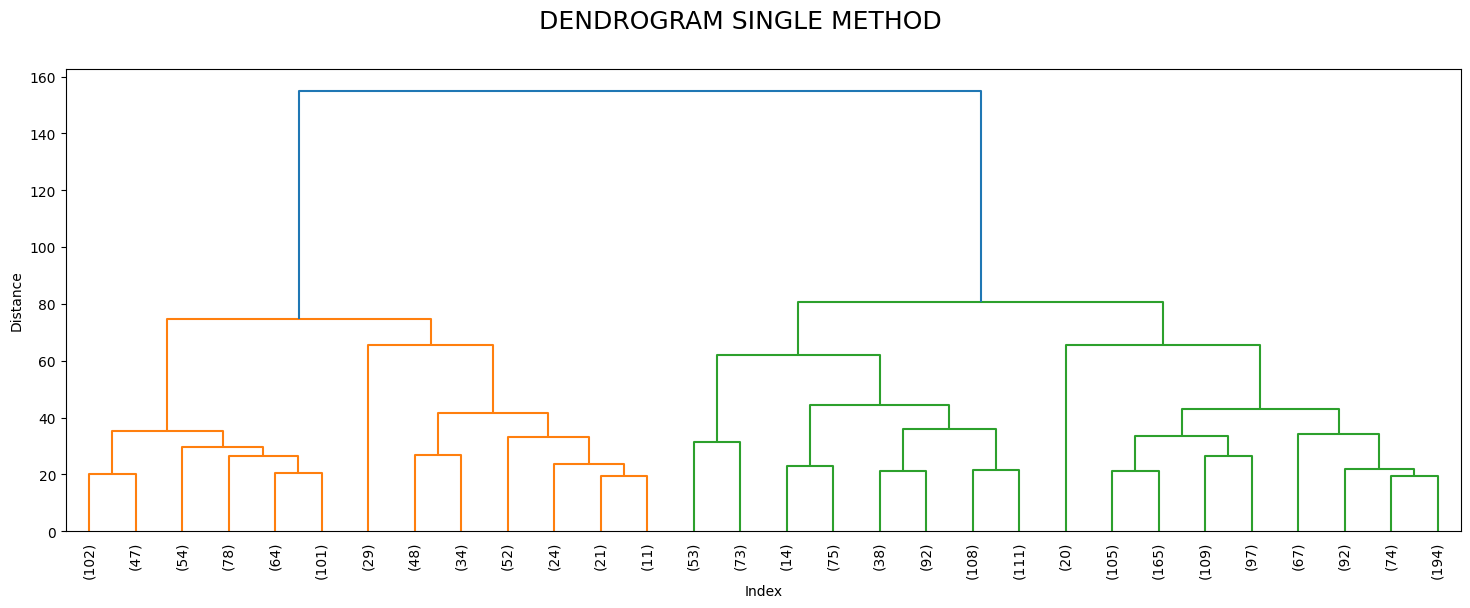

In [248]:
dist_sin = linkage(X_, method="ward")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90,truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [251]:
X_['4_clust'] = fcluster(dist_sin, 4, criterion='maxclust')

s_4 = metrics.silhouette_score(X_, X_['4_clust'], metric='euclidean')

print(f'Silhouette Coefficient for the data Dataset Clusters: {s_4:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.17


/tmp/ipykernel_1779/1458698633.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [252]:
fig_fcl_4= px.scatter_3d(
    df_,
    x='Income',
    y='NumWebVisitsMonth',
    z='NumStorePurchases',
    color=X_['4_clust'].astype(str),
    # hover_data=['NumStorePurchases', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases'],
    title='Customer Segments — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig_fcl_4.update_traces(marker=dict(size=4))
fig_fcl_4.update_layout(legend_title_text='Cluster')
fig_fcl_4.show()

Візуально ця кластеризація виглядає цікавіше (більш розмежування кластерів), але все ще вони налязять один на одного. Метрика також низька 0.17. Потрібно продовжувати досліджувати (спробувати додатковий фіче інженіринг, інші методи кластеризації)